# CHAOS IN A THREE-SPECIES FOOD CHAIN

### Alan Hasting and Thomas Powell

A continuous time model of a food chain incorporating nonlinear functional (and numerical) responses exhibits chaotic dynamics in long-term behavior when biologically reasonable parameter values are chosen. The appearance of chaos in this model suggests that chaotic dynamics may be common in natural food webs.

In [102]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.integrate import solve_ivp

import warnings
warnings.filterwarnings("ignore")

plt.rc("font", family="serif")
plt.rc("axes", titlesize=14, labelsize=12)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)
plt.rc("legend", fontsize=10)

Il sistema originale è:

$$
\begin{aligned}
\frac{dX}{dT} &= R_0 X \left(1 - \frac{X}{K_0}\right) - C_1 F_1(X) Y \\
\frac{dY}{dT} &= F_1(X) Y - F_2(Y) Z - D_1 Y \\
\frac{dZ}{dT} &= C_2 F_2(Y) Z - D_2 Z
\end{aligned}
$$

Con $F_i(U) = \dfrac{A_i U}{B_i + U}$ per $i = 1, 2$.

- $R_0$ è il tasso di crescita intrinseco di $X$.
- $K_0$ è la carrying capacity di $X$.
- $C_1^{-1}$ e $C_2$ sono i tassi di conversione delle prede a predatori per le specie $Y, Z$ 
- $d_1, d_2$ sono i tassi di mortalità dei predatori $Y, Z$.
- $A_1, A_2, B_1, B_2$ parametrizzano le risposte funzionali saturanti di tipo II.

Prima di analizzare il sistema, lo adimensionalizziamo per ridurre il numero di parametri da 10 a 6, ponendo:

$$
\begin{aligned}
x &= X/K_0 \\
y &= C_1 Y/K_0 \\
z &= C_1 Z /(C_2K_0) \\
t &= R_0 T
\end{aligned}
$$

Il sistema adimensionalizzato di $x, y, z$ è:

$$
\begin{aligned}
\dot{x} &= x(1 - x) - f_1(x)y \\
\dot{y} &= f_1(x)y - f_2(y)z - d_1 y \\
\dot{z} &= f_2(y)z - d_2 z
\end{aligned}
$$

Con $f_i(u) = \dfrac{a_i u}{1 + b_i u}$ per $i = 1, 2$.

Abbiamo che $x(1 - x)$ è la crescita logistica di $x$ in assenza di predatori.  

I due tassi $f_1, f_2$ sono "saturating functional responses" di tipo II. 

In generale $f(u) = \dfrac{au}{1+ahu}$ ("the consumer is limited by its capacity to process food").

- $a$ attack rate: il tasso al quale il consumatore incontra il cibo per unità di densità di cibo.
- $h$ handling time: tempo necessario per processare un'unità di cibo.

Nel paper $b := ah$, avremo quindi quattro parametri: $a_1, a_2, b_1, b_2$ per queste funzioni.

Quindi $f_1(x)y$ rappresenta quanto cresce la popolazione $y$ rispetto alle prede $x$ (discorso analogo per $f_2(x)$ con popolazioni $y$ e $z$).

Gli ultimi 2 parametri $d_1, d_2$ sono semplicemente i tassi di mortalità naturale dei predatori $y, z$.

Proviamo a vedere come si comporta $f_i(x)$ con un esempio:

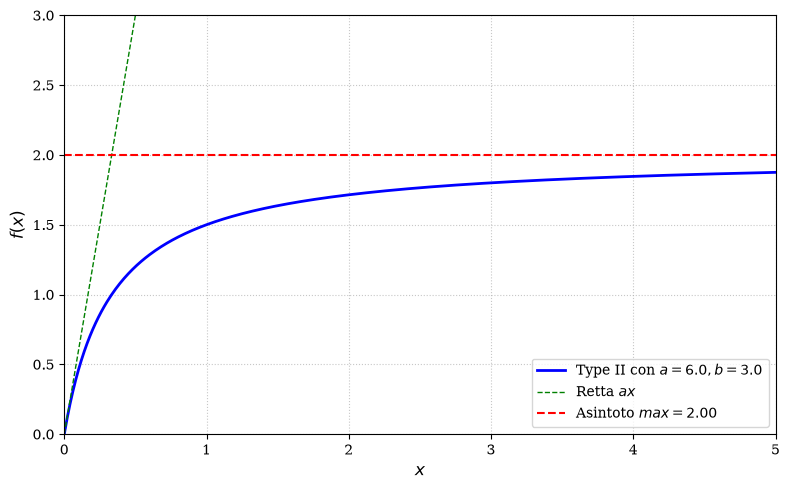

In [103]:
a = 6.0
b = 3.0

x = np.linspace(0, 10, 1000)
f_x = (a * x) / (1.0 + b * x)

ax = a * x
asintoto = a / b

plt.figure(figsize=(8, 5))

plt.plot(x, f_x, 'b-', linewidth=2, label=f'Type II con $a={a}, b={b}$')
plt.plot(x, ax, 'g--', linewidth=1, label="Retta $ax$")

plt.axhline(y=asintoto, color='r', linestyle='--', label=f'Asintoto $max = {asintoto:.2f}$')

plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.xlim(0, 5)
plt.ylim(0, asintoto + 1)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Tornando al paper, i parametri sono esattamente quelli descritti nella Tabella 1 per far emergere il comportamento caotico. Inoltre definiamo il modello di Hastings-Powell:

In [104]:
a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d1 = 0.4
d2 = 0.01

params = (a1, a2, b1, b2, d1, d2)

def hastings_powell(t, state, a1, a2, b1, b2, d1, d2):
    x, y, z = state

    f1 = (a1 * x) / (1.0 + b1 * x)
    f2 = (a2 * y) / (1.0 + b2 * y)

    dxdt = x * (1.0 - x) - f1 * y
    dydt = f1 * y - f2 * z - d1 * y
    dzdt = f2 * z - d2 * z

    return np.array([dxdt, dydt, dzdt])

Equilibri del sistema:

In [105]:
def f1_eval(x): return (a1 * x) / (1.0 + b1 * x)
def f2_eval(y): return (a2 * y) / (1.0 + b2 * y)

def jacobian(x, y, z):
    df1_dx = a1 / ((1.0 + b1 * x)**2)
    df2_dy = a2 / ((1.0 + b2 * y)**2)
    
    J11 = 1.0 - 2.0*x - df1_dx * y
    J12 = -f1_eval(x)
    J13 = 0.0
    
    J21 = df1_dx * y
    J22 = f1_eval(x) - df2_dy * z - d1
    J23 = -f2_eval(y)
    
    J31 = 0.0
    J32 = df2_dy * z
    J33 = f2_eval(y) - d2
    
    return np.array([[J11, J12, J13],
                     [J21, J22, J23],
                     [J31, J32, J33]])

# E0: Estinzione totale
E0 = (0.0, 0.0, 0.0)
eig0 = np.linalg.eigvals(jacobian(*E0))
print(f"E0 = {E0}")
print(f"Autovalori: {np.round(eig0, 3)}\n")

# E1: Sopravvivenza sola preda
E1 = (1.0, 0.0, 0.0)
eig1 = np.linalg.eigvals(jacobian(*E1))
print(f"E1 = {E1}")
print(f"Autovalori: {np.round(eig1, 3)}\n")

# E2: Coesistenza preda-predatore
x2 = d1 / (a1 - d1 * b1)
y2 = (1.0 - x2) * (1.0 + b1 * x2) / a1
E2 = (x2, y2, 0.0)
eig2 = np.linalg.eigvals(jacobian(*E2))
print(f"E2 = ({x2:.3f}, {y2:.3f}, 0.000)")
print(f"Autovalori: {np.round(eig2, 3)}\n")

# E3: Coesistenza globale a 3 livelli
y3 = d2 / (a2 - d2 * b2)
coeff = [b1, -(b1 - 1.0), (a1 * y3 - 1.0)]
roots = np.roots(coeff)
x3 = min([r for r in roots if r > 0])
z3 = (f1_eval(x3) - d1) * y3 / f2_eval(y3)
E3 = (x3, y3, z3)
eig3 = np.linalg.eigvals(jacobian(*E3))
print(f"E3 = ({x3:.3f}, {y3:.3f}, {z3:.3f})")
print(f"Autovalori: {np.round(eig3, 3)}")


E0 = (0.0, 0.0, 0.0)
Autovalori: [ 1.  +0.j -0.4 +0.j -0.01+0.j]

E1 = (1.0, 0.0, 0.0)
Autovalori: [-1.  +0.j  0.85+0.j -0.01+0.j]

E2 = (0.105, 0.235, 0.000)
Autovalori: [0.055+0.519j 0.055-0.519j 0.006+0.j   ]

E3 = (0.819, 0.125, 9.808)
Autovalori: [-0.611+0.j     0.039+0.075j  0.039-0.075j]


Usiamo `solve_ivp` per risolvere il sistema nel tempo:

In [106]:
t_span = (0, 10_000)

t_eval = np.linspace(5000, 6500, 30_000)

initial_state = [0.8, 0.2, 8.0]

sol = solve_ivp(
    hastings_powell, 
    t_span, 
    initial_state, 
    args=params, 
    method='RK45', 
    t_eval=t_eval
)

time_steps = sol.t
x_points, y_points, z_points = sol.y

Analizziamo quindi come variano le popolazioni nel tempo:

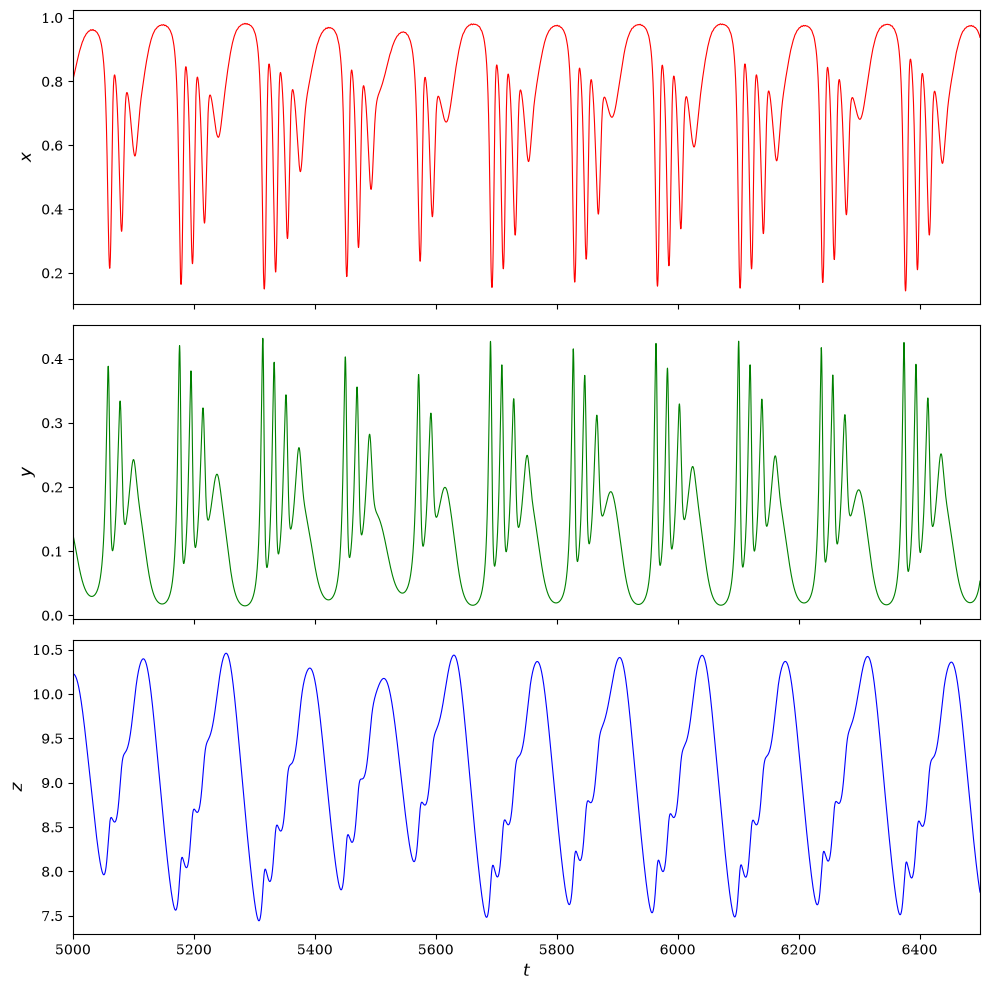

In [107]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(time_steps, x_points, color='red', linewidth=0.8)
ax1.set_ylabel('$x$')

ax2.plot(time_steps, y_points, color='green', linewidth=0.8)
ax2.set_ylabel('$y$')

ax3.plot(time_steps, z_points, color='blue', linewidth=0.8)
ax3.set_ylabel('$z$')

ax3.set_xlabel('$t$')

ax3.set_xlim(5000, 6500)

plt.tight_layout()
plt.show()

Diagramma delle fasi:

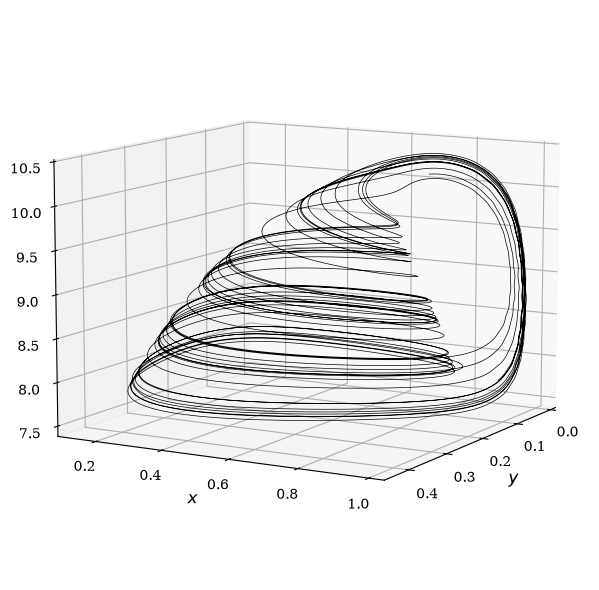

In [108]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# scambio gli assi per avere l'orientamento come nel paper
ax.plot(y_points, x_points, z_points, color='black', linewidth=0.5)

ax.set_xlabel('$y$')
ax.set_ylabel('$x$')
ax.set_zlabel('$z$')

ax.view_init(elev=10, azim=30, roll=0)

plt.tight_layout()
plt.show()

In [109]:

fig_anim = plt.figure(figsize=(8, 6))
ax_anim = fig_anim.add_subplot(111, projection='3d')
ax_anim.set_xlabel('$y$')
ax_anim.set_ylabel('$x$')
ax_anim.set_zlabel('$z$')
ax_anim.view_init(elev=10, azim=30)

line, = ax_anim.plot([], [], [], color='black', linewidth=0.5)

ax_anim.set_xlim(min(y_points), max(y_points))
ax_anim.set_ylim(min(x_points), max(x_points))
ax_anim.set_zlim(min(z_points), max(z_points))

def init():
    line.set_data([], [])
    line.set_3d_properties([])
    return line,

def update(frame):
    idx = frame * 100
    line.set_data(y_points[:idx], x_points[:idx])
    line.set_3d_properties(z_points[:idx])
    return line,

ani = animation.FuncAnimation(fig_anim, update, frames=len(x_points)//100, init_func=init, blit=True)
ani.save('video/caos_3d.mp4', fps=30, extra_args=['-vcodec', 'libx264'])
plt.close(fig_anim)
print('Done.')


Done.


X perturbato -> effetto farfalla:

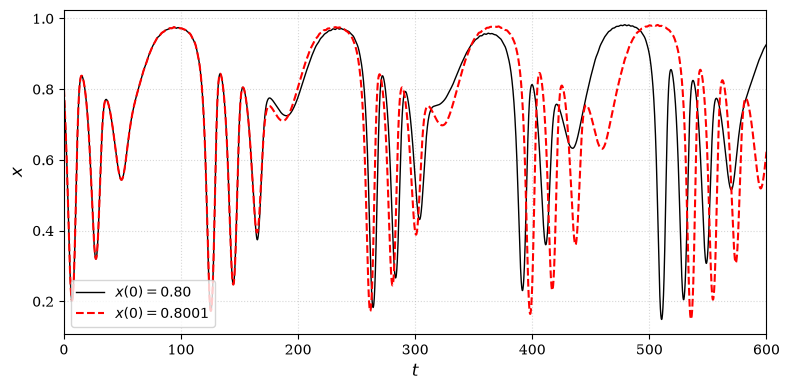

In [110]:
t_span_divergence = (0, 600)
t_eval_divergence = np.linspace(0, 600, 5000)

eps = 1e-4

initial_state_001 = [0.8 + eps, 0.2, 8.0]

sol_1 = solve_ivp(
    hastings_powell, 
    t_span_divergence, 
    initial_state, 
    args=params, 
    t_eval=t_eval_divergence, 
    method='RK45'
)

sol_2 = solve_ivp(
    hastings_powell, 
    t_span_divergence, 
    initial_state_001, 
    args=params, 
    t_eval=t_eval_divergence, 
    method='RK45'
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(sol_1.t, sol_1.y[0], color='black', linewidth=1, label='$x(0) = 0.80$')
ax.plot(sol_2.t, sol_2.y[0], color='red', linewidth=1.5, linestyle='--', label=f'$x(0) = {0.80 + eps}$')

ax.set_xlabel('$t$')
ax.set_ylabel('$x$')
ax.set_xlim(0, 600)
ax.legend(loc='lower left')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

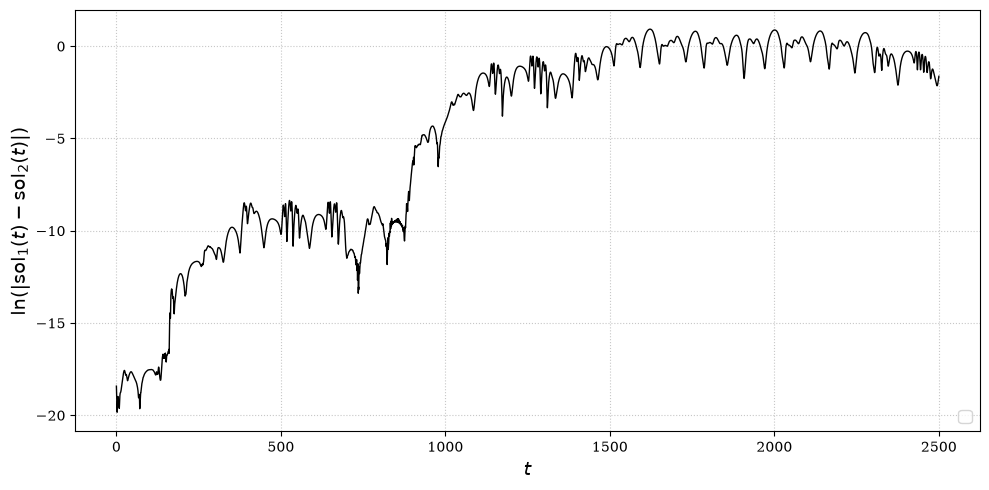

In [111]:
t_span_lyap = (0, 2500)
t_eval_lyap = np.linspace(0, 2500, 8000)

eps = 1e-8
initial_state_eps = [0.8 + eps, 0.2, 8.0]

sol1 = solve_ivp(hastings_powell, t_span_lyap, initial_state, args=params, t_eval=t_eval_lyap, method='RK45')
sol2 = solve_ivp(hastings_powell, t_span_lyap, initial_state_eps, args=params, t_eval=t_eval_lyap, method='RK45')

dist = np.sqrt((sol1.y[0] - sol2.y[0])**2 + (sol1.y[1] - sol2.y[1])**2 + (sol1.y[2] - sol2.y[2])**2)
log_dist = np.log(dist)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sol1.t, log_dist, color='black', linewidth=1)

ax.set_xlabel(r'$t$', fontsize=14)
ax.set_ylabel(r'$\ln(|\text{sol}_1(t) - \text{sol}_2(t)|)$', fontsize=14)
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Diagrammi di biforcazione:

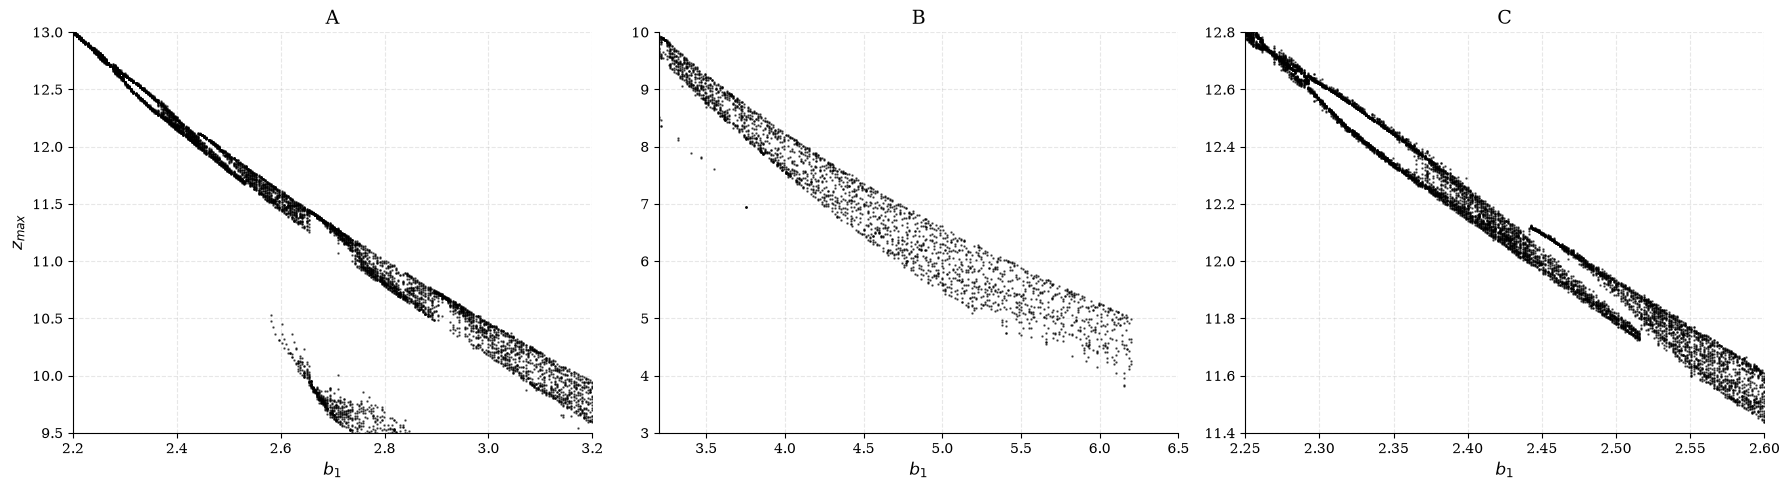

In [112]:
qq = 250
t_transient = 800
t_eval = 1200
ode_method = "RK45"

def find_z_maxima_event(t, state, a1, a2, b1, b2, d1, d2):
    x, y, z = state
    f2 = (a2 * y) / (1.0 + b2 * y)
    return f2 * z - d2 * z

find_z_maxima_event.direction = -1
find_z_maxima_event.terminal = False

def compute_bifurcation_sweep(b1_array, initial_ic):
    b1_res = []
    zmax_res = []

    first_b1 = b1_array[0]
    first_params = (a1, a2, first_b1, b2, d1, d2)

    sol_init = solve_ivp(
        hastings_powell, (0, t_transient), initial_ic, args=first_params,
        method=ode_method
    )
    ic = sol_init.y[:, -1]

    for b1_val in b1_array:
        current_params = (a1, a2, b1_val, b2, d1, d2)

        sol_eval = solve_ivp(
            hastings_powell, (0, t_eval), ic, args=current_params,
            method=ode_method, events=find_z_maxima_event
        )
        ic = sol_eval.y[:, -1]

        if sol_eval.y_events[0].size > 0:
            z_peaks = sol_eval.y_events[0][:, 2]
            max_z = np.max(z_peaks)
            z_filtered = z_peaks[z_peaks > 0.85 * max_z]
            b1_res.extend([b1_val] * len(z_filtered))
            zmax_res.extend(z_filtered)

    return b1_res, zmax_res, ic

ic_standard = [0.8, 0.2, 8.0]

configs = [
    ("A", 2.20, 3.2, 3.2, (9.5, 13.0)),
    ("B", 3.20, 6.2, 6.5, (3.0, 10.0)),
    ("C", 2.25, 2.6, 2.6, (11.4, 12.8))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_kwargs = {"color": "black", "marker": ".", "linestyle": "None", "alpha": 0.6, "markersize": 1.5}

for idx, (ax, (name, b1_start, b1_end, x_lim_max, ylims)) in enumerate(zip(axes, configs)):
    b1_vals = np.linspace(b1_start, b1_end, qq)

    b1_f, z_f, ic_end = compute_bifurcation_sweep(b1_vals, ic_standard)
    b1_b, z_b, _ = compute_bifurcation_sweep(b1_vals[::-1], ic_end)

    ax.plot(b1_f, z_f, **plot_kwargs)
    ax.plot(b1_b, z_b, **plot_kwargs)
    
    ax.set_title(f"{name}")
    ax.set_xlabel(r"$b_1$", fontsize=12)
    if idx == 0:
        ax.set_ylabel(r"$z_{max}$", fontsize=12)
    
    ax.set_xlim(b1_start, x_lim_max)
    ax.set_ylim(ylims)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Controllo tramite harvesting:

In [113]:
def hastings_powell_harvesting(t, state, a1, a2, b1, b2, d1, d2, H):
    x, y, z = state
    f1 = (a1 * x) / (1.0 + b1 * x)
    f2 = (a2 * y) / (1.0 + b2 * y)
    dxdt = x * (1.0 - x) - f1 * y
    dydt = f1 * y - f2 * z - d1 * y
    dzdt = f2 * z - d2 * z - H * z
    return np.array([dxdt, dydt, dzdt])

Biforcazione con H:

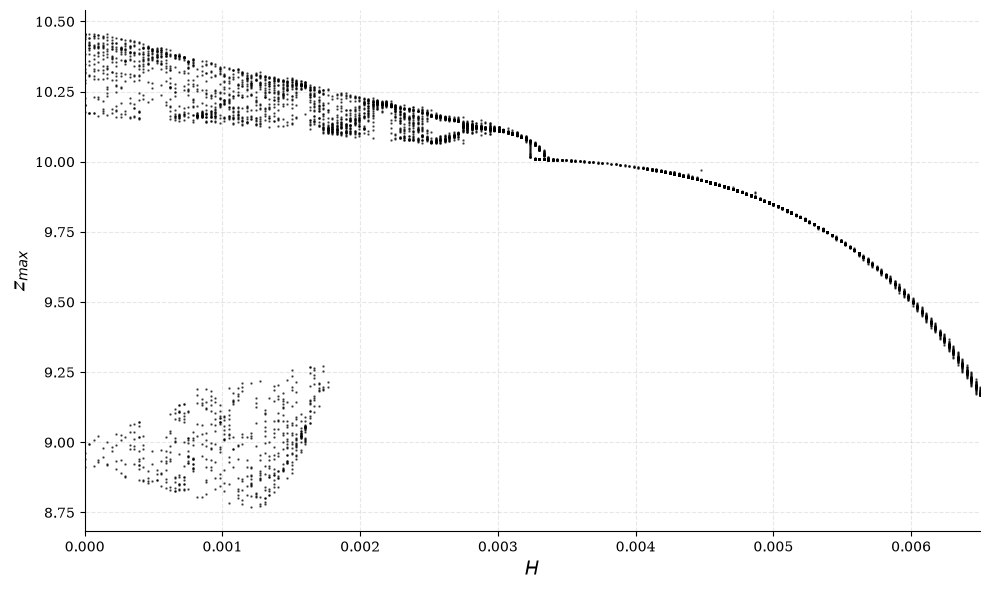

In [114]:
qq_H = 200
t_transient_H = 1000
t_eval_H = 1200
ode_method = "RK45"

def find_z_maxima_event_H(t, state, a1, a2, b1, b2, d1, d2, H):
    x, y, z = state
    f2 = (a2 * y) / (1.0 + b2 * y)
    return f2 * z - d2 * z - H * z

find_z_maxima_event_H.direction = -1
find_z_maxima_event_H.terminal = False

def compute_bifurcation_sweep_H(H_array, initial_ic):
    H_res = []
    zmax_res = []
    
    first_H = H_array[0]
    first_params = (a1, a2, 3.0, b2, d1, d2, first_H)
    
    sol_init = solve_ivp(
        hastings_powell_harvesting, (0, t_transient_H), initial_ic, args=first_params,
        method=ode_method
    )
    ic = sol_init.y[:, -1]
    
    for H_val in H_array:
        current_params = (a1, a2, 3.0, b2, d1, d2, H_val)
        
        sol_eval = solve_ivp(
            hastings_powell_harvesting, (0, t_eval_H), ic, args=current_params,
            method=ode_method, events=find_z_maxima_event_H
        )
        ic = sol_eval.y[:, -1]
        
        if ic[2] < 1e-3:
            H_res.append(H_val)
            zmax_res.append(0.0)
        elif sol_eval.y_events[0].size > 0:
            z_peaks = sol_eval.y_events[0][:, 2]
            if len(z_peaks) > 0:
                max_z = np.max(z_peaks)
                z_filtered = z_peaks[z_peaks > 0.85 * max_z]
                H_res.extend([H_val] * len(z_filtered))
                zmax_res.extend(z_filtered)
        else:
            H_res.append(H_val)
            zmax_res.append(ic[2])

    return H_res, zmax_res, ic

ic_standard = [0.8, 0.2, 8.0]
H_start, H_end = 0.0, 0.0065

fig = plt.figure(figsize=(10, 6))
plot_kwargs = {"color": "black", "marker": ".", "linestyle": "None", "alpha": 0.6, "markersize": 1.5}

H_vals = np.linspace(H_start, H_end, qq_H)
H_f, z_f, ic_end = compute_bifurcation_sweep_H(H_vals, ic_standard)
H_b, z_b, _ = compute_bifurcation_sweep_H(H_vals[::-1], ic_end)

plt.plot(H_f, z_f, **plot_kwargs)
plt.plot(H_b, z_b, **plot_kwargs)

plt.xlabel(r"$H$", fontsize=14)
plt.ylabel(r"$z_{max}$", fontsize=14)
plt.xlim(H_start, H_end)
plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

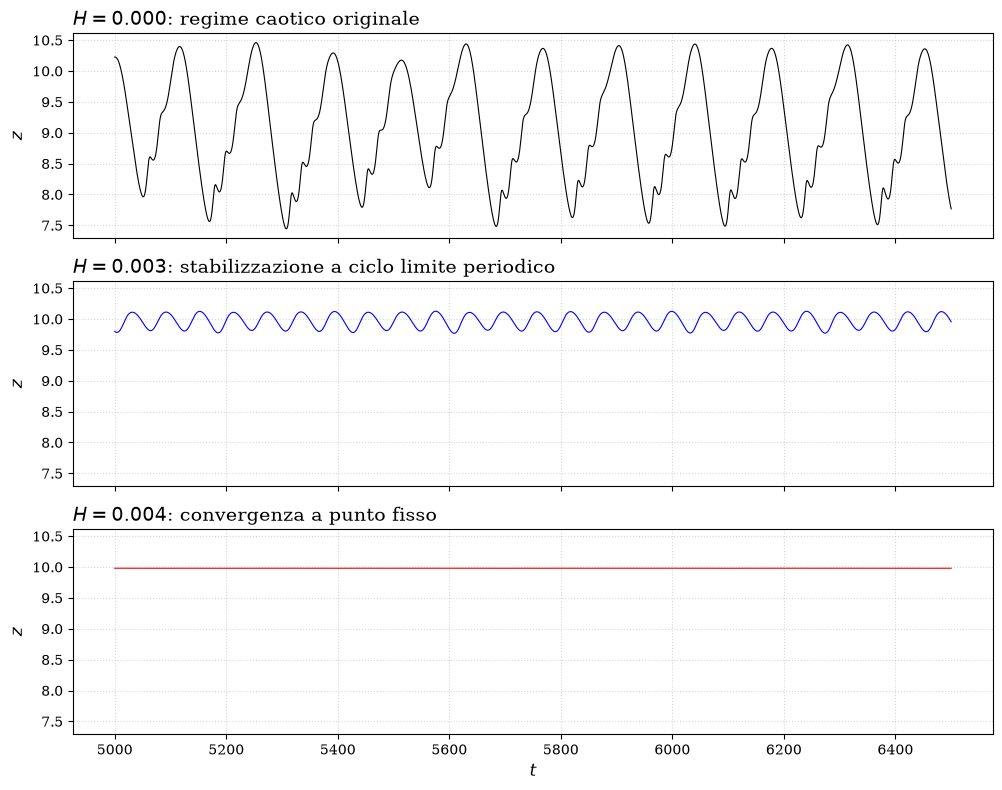

In [115]:
t_span = (0, 7000)
t_eval = np.linspace(5000, 6500, 15000)
initial_state = [0.8, 0.2, 8.0]
harvests = [0.0, 0.003, 0.004]
titles = [
    "$H = 0.000$: regime caotico originale",
    "$H = 0.003$: stabilizzazione a ciclo limite periodico",
    "$H = 0.004$: convergenza a punto fisso"
]
colors = ["black", "blue", "red"]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)
for idx, (H_val, title_text, col) in enumerate(zip(harvests, titles, colors)):
    sol = solve_ivp(
        hastings_powell_harvesting, t_span, initial_state, args=(a1, a2, 3.0, b2, d1, d2, H_val), 
        t_eval=t_eval, method="RK45"
    )
    x, y, z = sol.y
    axes[idx].plot(t_eval, z, color=col, linewidth=0.8)
    axes[idx].set_title(title_text, loc="left")
    axes[idx].set_ylabel("$z$")
    axes[idx].grid(True, linestyle=":", alpha=0.5)

axes[2].set_xlabel("$t$")
plt.tight_layout()
plt.show()

Spazio delle fasi con harvesting:

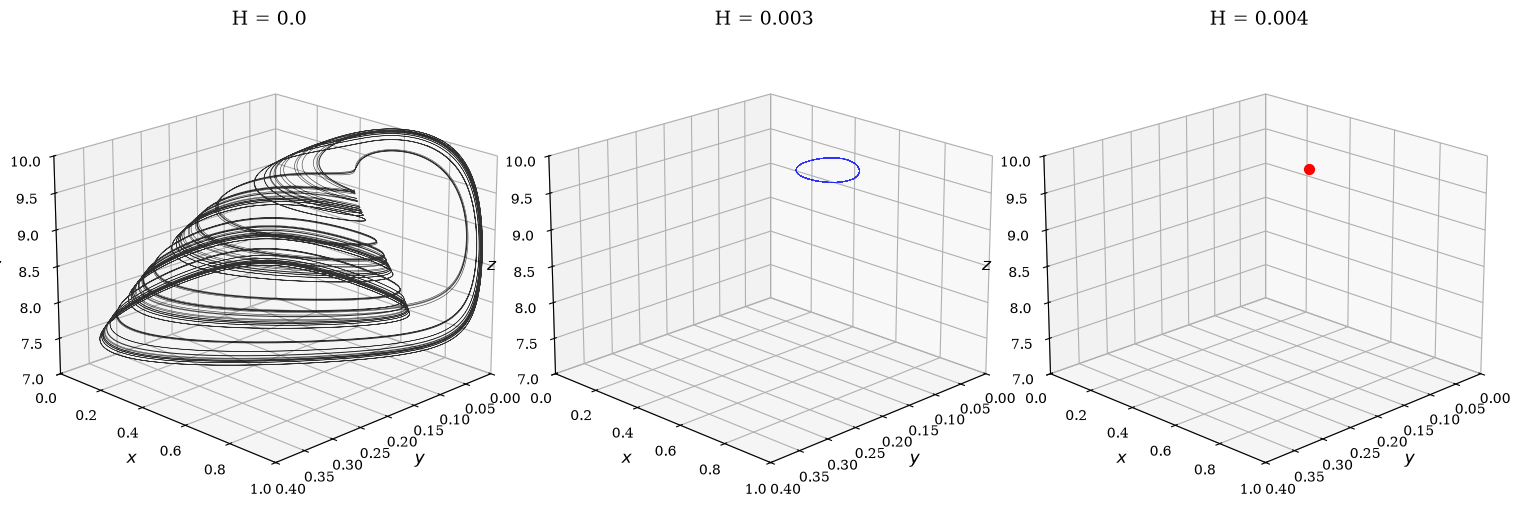

In [116]:
fig = plt.figure(figsize=(15, 6))

t_span_3d = (0, 8000)
t_eval_3d = np.linspace(5000, 8000, 30000)

for idx, (H_val, title_text, col) in enumerate(zip(harvests, titles, colors)):
    sol_3d = solve_ivp(
        hastings_powell_harvesting, t_span_3d, initial_state, 
        args=(a1, a2, 3.0, b2, d1, d2, H_val),
        t_eval=t_eval_3d, method="RK45", rtol=1e-8, atol=1e-8
    )
    
    x_3d = sol_3d.y[0, :]
    y_3d = sol_3d.y[1, :]
    z_3d = sol_3d.y[2, :]
    
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    if H_val == 0.004:
        ax.scatter(y_3d[-1:], x_3d[-1:], z_3d[-1:], color=col, s=50)
        ax.plot(y_3d, x_3d, z_3d, color=col, linewidth=0.4, alpha=0.5)
    else:
        ax.plot(y_3d, x_3d, z_3d, color=col, linewidth=0.4, alpha=0.8)
    
    ax.set_title(f"H = {H_val}")
    ax.set_xlabel('$y$')
    ax.set_ylabel('$x$')
    ax.set_zlabel('$z$')
    
    ax.set_xlim(0.0, 0.4)
    ax.set_ylim(0.0, 1.0)
    ax.set_zlim(7.0, 10.0)
    
    ax.view_init(elev=20, azim=45, roll=0)

plt.tight_layout()
plt.show()

Per confermare in modo analitico che l'introduzione dell'harvesting abbia creato un punto fisso stabilmente asintotico, calcoliamo la Jacobiana:

$$
J = \begin{pmatrix}
1 - 2x - \frac{a_1 y}{(1+b_1 x)^2} & -\frac{a_1 x}{1+b_1 x} & 0 \\
\frac{a_1 y}{(1+b_1 x)^2} & \frac{a_1 x}{1+b_1 x} - \frac{a_2 z}{(1+b_2 y)^2} - d_1 & -\frac{a_2 y}{1+b_2 y} \\
0 & \frac{a_2 z}{(1+b_2 y)^2} & \frac{a_2 y}{1+b_2 y} - (d_2+H)
\end{pmatrix}
$$

In [117]:
H_stable = 0.004

sol_eq = solve_ivp(
    hastings_powell_harvesting, (0, 20000), initial_state, 
    args=(a1, a2, 3.0, b2, d1, d2, H_stable),
    method="RK45", rtol=1e-10, atol=1e-10
)
x_star, y_star, z_star = sol_eq.y[:, -1]

print(f"E*: x={x_star:.4f}, y={y_star:.4f}, z={z_star:.4f}\n")

def compute_jacobian(x, y, z, a1, a2, b1, b2, d1, d2, H):
    J = np.zeros((3, 3))
    J[0, 0] = 1 - 2*x - (a1 * y) / ((1 + b1 * x)**2)
    J[0, 1] = -(a1 * x) / (1 + b1 * x)
    J[0, 2] = 0
    J[1, 0] = (a1 * y) / ((1 + b1 * x)**2)
    J[1, 1] = (a1 * x) / (1 + b1 * x) - (a2 * z) / ((1 + b2 * y)**2) - d1
    J[1, 2] = -(a2 * y) / (1 + b2 * y)
    J[2, 0] = 0
    J[2, 1] = (a2 * z) / ((1 + b2 * y)**2)
    J[2, 2] = (a2 * y) / (1 + b2 * y) - (d2 + H)
    return J

J_eq = compute_jacobian(x_star, y_star, z_star, a1, a2, 3.0, b2, d1, d2, H_stable)

eigenvalues = np.linalg.eigvals(J_eq)

for i, ev in enumerate(eigenvalues):
    print(f"\u03BB_{i+1} = {ev.real:.5f} {'+' if ev.imag >= 0 else '-'} {abs(ev.imag):.5f}j")

print()
if all(ev.real < 0 for ev in eigenvalues):
    print("LAS")
else:
    print("Instabile")


E*: x=0.6803, y=0.1944, z=9.9802

λ_1 = -0.19357 + 0.00000j
λ_2 = -0.03546 + 0.12715j
λ_3 = -0.03546 - 0.12715j

LAS


Evoluzione temporale:

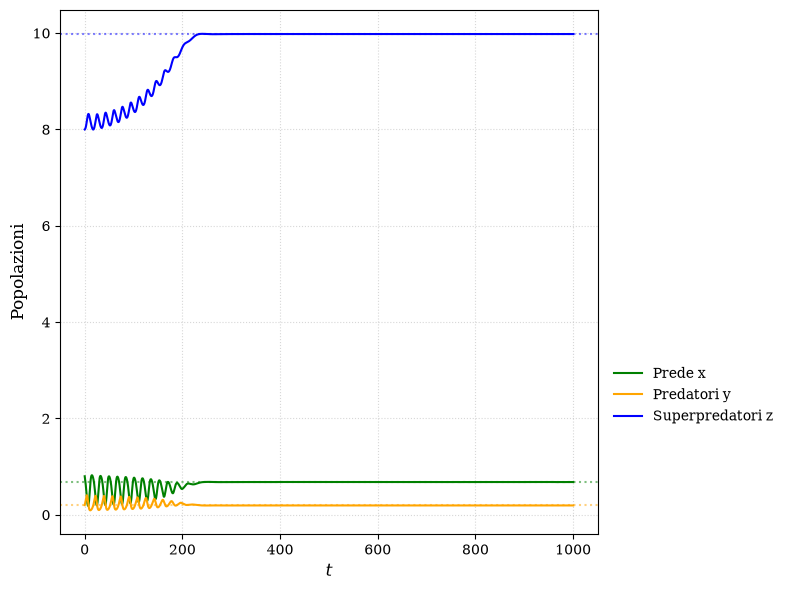

In [118]:
t_span_ev = (0, 1000)
t_eval_ev = np.linspace(0, 1000, 15000)

sol_ev = solve_ivp(
    hastings_powell_harvesting, t_span_ev, initial_state,
    args=(a1, a2, 3.0, b2, d1, d2, H_stable),
    t_eval=t_eval_ev, method="RK45"
)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(sol_ev.t, sol_ev.y[0], label="Prede x", color="green", linewidth=1.5)
ax1.plot(sol_ev.t, sol_ev.y[1], label="Predatori y", color="orange", linewidth=1.5)
ax1.plot(sol_ev.t, sol_ev.y[2], label="Superpredatori z", color="blue", linewidth=1.5)

ax1.axhline(y=x_star, color='green', linestyle=':', alpha=0.5)
ax1.axhline(y=y_star, color='orange', linestyle=':', alpha=0.5)
ax1.axhline(y=z_star, color='blue', linestyle=':', alpha=0.5)

ax1.set_xlabel("$t$")
ax1.set_ylabel("Popolazioni")
ax1.legend(loc='lower left', bbox_to_anchor=(1.02, 0.2), borderaxespad=0, frameon=False)
ax1.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

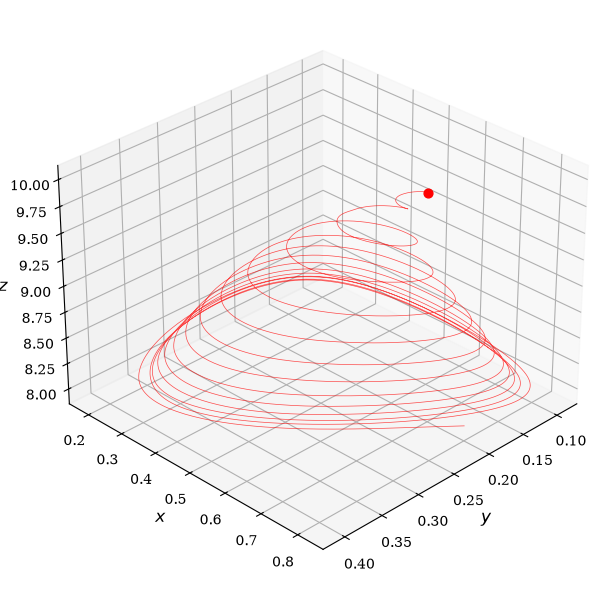

In [119]:
fig = plt.figure(figsize=(8, 6))
ax2 = fig.add_subplot(1, 1, 1, projection='3d')

ax2.plot(sol_ev.y[1], sol_ev.y[0], sol_ev.y[2], color='red', linewidth=0.5, alpha=0.7)
ax2.scatter([y_star], [x_star], [z_star], color='red', s=40, zorder=10)

ax2.set_xlabel('$y$')
ax2.set_ylabel('$x$')
ax2.set_zlabel('$z$')
ax2.legend(loc="upper right", frameon=False)

ax2.view_init(elev=30, azim=45, roll=0)

plt.tight_layout()
plt.show()

In [120]:
fig_anim2 = plt.figure(figsize=(10, 8))
ax_anim2 = fig_anim2.add_subplot(111, projection='3d')
ax_anim2.set_xlabel('Prede x')
ax_anim2.set_ylabel('Predatori y')
ax_anim2.set_zlabel('Superpredatori z')
ax_anim2.view_init(elev=20, azim=130)

line2, = ax_anim2.plot([], [], [], color='purple', linewidth=0.8)
point2, = ax_anim2.plot([], [], [], marker='o', color='red')

x_ev = sol_ev.y[0]
y_ev = sol_ev.y[1]
z_ev = sol_ev.y[2]

ax_anim2.set_xlim(min(x_ev), max(x_ev))
ax_anim2.set_ylim(min(y_ev), max(y_ev))
ax_anim2.set_zlim(min(z_ev), max(z_ev))

def init2():
    line2.set_data([], [])
    line2.set_3d_properties([])
    point2.set_data([], [])
    point2.set_3d_properties([])
    return line2, point2

def update2(frame):
    idx = frame * 50
    line2.set_data(x_ev[:idx], y_ev[:idx])
    line2.set_3d_properties(z_ev[:idx])
    point2.set_data([x_ev[idx]], [y_ev[idx]])
    point2.set_3d_properties([z_ev[idx]])
    return line2, point2

ani2 = animation.FuncAnimation(fig_anim2, update2, frames=len(x_ev)//50 - 1, init_func=init2, blit=True)
ani2.save('video/evoluzione_3d.mp4', fps=30, extra_args=['-vcodec', 'libx264'])
plt.close(fig_anim2)
print('Done.')

Done.
